## In-Depth Exploratory Data Analysis (EDA) of Netflix's Content strategy
Exploring trends in content production, identify popular genres, analyze content ratings, and understand the distribution of movies and TV shows on the platform.

## Step 1 - Import required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud
from rich import print

sns.set(style="darkgrid")

## Step 2 - importing data and inspecting

In [2]:
df = pd.read_csv(r"C:\tut\21-days-21-projects\21-Days-21-Projects-Dataset\Datasets\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:
df.shape

(7787, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


**Interpretation of .info()**

* We have 7787 entries.
* **Key Problems**: The **date_added** column is of type object (a string), not a datetime object, We cannot perform time-based analysis until it's corrected.
* **Missing value**: **director**, **cast**, **country**, **date_added**, and **rating** all have missing values, **director** has the most significant number of nulls.

## Step 3 - Data Cleaning and Transformation

In [5]:
## Checking the missing values for column
df.isnull().sum() 

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [6]:
## Handling missing values for "Director" and "Cast"
## Inplace=True for series data won't work, Inplace changes the original data
df['director'] = df['director'].fillna("Unknown")

In [7]:
df['cast'] = df['cast'].fillna("Unknown")

In [8]:
df['country'] = df['country'].fillna(df["country"].mode()[0])

In [9]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
listed_in        0
description      0
dtype: int64

In [10]:
## dropping values from exactly date_addedd and ratings
df.dropna(subset=["date_added", "rating"], inplace=True)

* **dayfirst:** If the date is ambiguous, assume the first number is the day.

* **format:** The values might have different formats. Figure them out individually.

In [11]:
## Converting str object into date_time object
df["date_added"] = pd.to_datetime(df['date_added'],format='mixed', dayfirst=True)

In [12]:
## Extracting Year and Month
df['year_added'] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  year_added    7770 non-null   int32         
 13  month_added   7770 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
memory usage: 849.8+ KB


In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

### Step 4: Exploratory Data Analysis & Visualisation

4.1 What is the distribution of content type?

In [15]:
counts = df['type'].value_counts()
print(counts)

type
Movie      5372
TV Show    2398
Name: count, dtype: int64

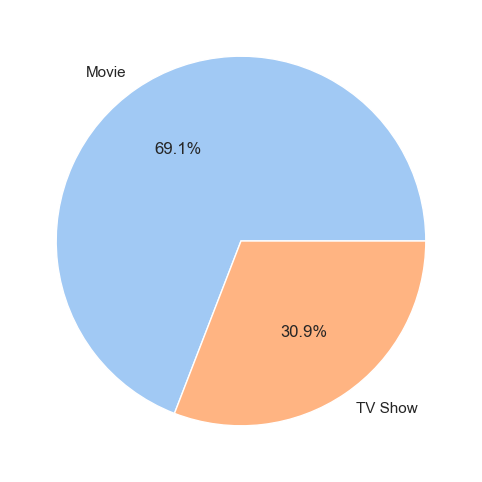

In [16]:
colors = sns.color_palette('pastel', len(df['type'].value_counts()))
plt.figure(figsize=(8,6))
plt.pie(counts, labels=counts.index, colors=colors, autopct="%1.1f%%")
plt.show()

**insight**: movies dominate the netflix content

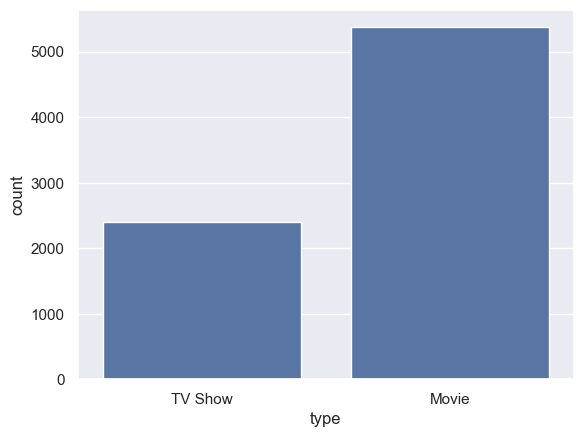

In [17]:
sns.countplot(data=df, x="type")
plt.show()

4.2 How has content been added over time?

groupby()
   
   ↓

Put similar things together


size()

   ↓

Count them


unstack()

   ↓

Turn groups into columns


fillna(0)

   ↓

Replace missing counts with 0

<Figure size 1400x800 with 0 Axes>

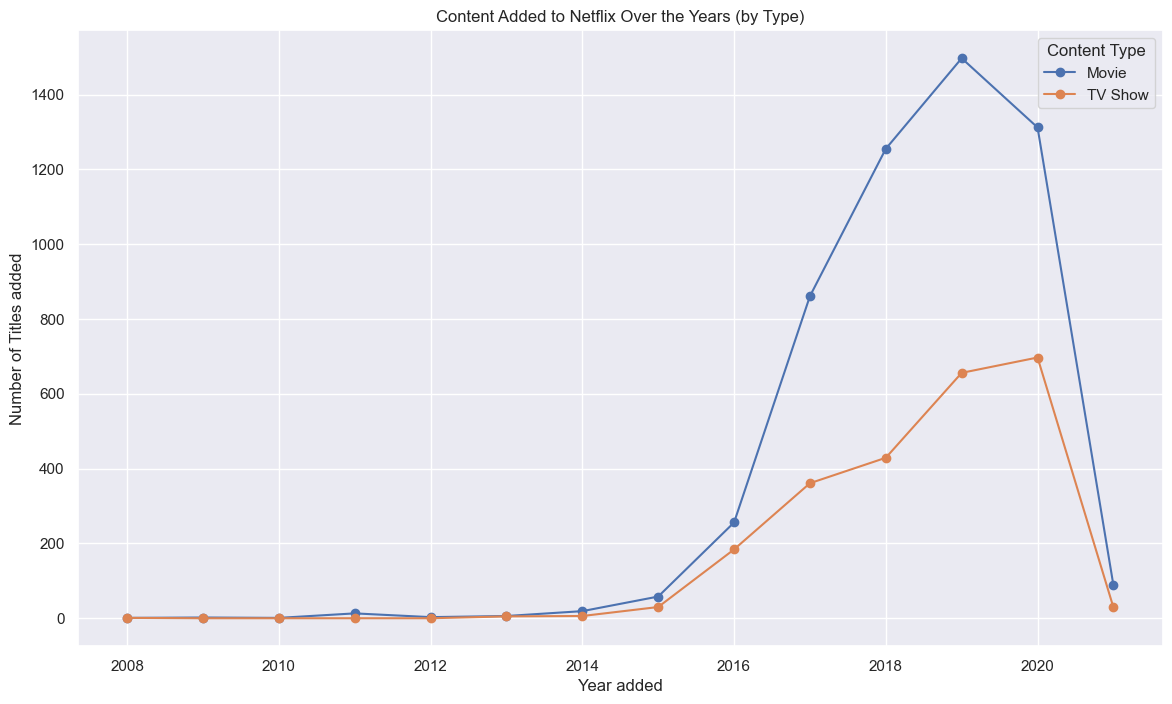

In [18]:
content_over_time = df.groupby(["year_added", 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind="line", marker="o", figsize=(14, 8))
plt.title("Content Added to Netflix Over the Years (by Type)")
plt.xlabel("Year added")
plt.ylabel("Number of Titles added")
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Key Insights**

**Movie Dominance:** Netflix added significantly more movies than TV shows annually, with movie additions peaking at nearly 1,500 titles in 2019—more than double the TV show peak in 2020 (~700 titles).

**Exponential Expansion (2015–2019):** Both content types saw minimal additions prior to 2015 before experiencing rapid growth between 2016 and 2019 as Netflix expanded global streaming investments.

**Post-2019 Drop:** Content additions dropped sharply in 2021, likely reflecting production delays during the COVID-19 pandemic or incomplete data for that calendar year.

4.3 What are the most Popular genres?

In [19]:
df["listed_in"].value_counts()

listed_in
Documentaries                                                334
Stand-Up Comedy                                              321
Dramas, International Movies                                 320
Comedies, Dramas, International Movies                       243
Dramas, Independent Movies, International Movies             215
                                                            ... 
Sports Movies                                                  1
Crime TV Shows, TV Horror, TV Mysteries                        1
Children & Family Movies, Classic Movies, Dramas               1
Romantic TV Shows, Spanish-Language TV Shows, TV Comedies      1
Dramas, Faith & Spirituality, Sports Movies                    1
Name: count, Length: 491, dtype: int64

**Theoretical Concept: Handling Multi-Value Text Columns**

The listed_in column contains strings with multiple genres separated by commas (e.g., "Dramas, International Movies"). To analyze each genre individually, we need to transform the data. A common technique is to:  

1. Split the string in each row into a list of genres.  

2. Explode the DataFrame so that each genre in the list gets its own row, duplicating the other information for that title. This allows us to perform a value_counts() on the genres.

In [20]:
genres = df.assign(genre=df["listed_in"].str.split(', ')).explode("genre")
genres.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies


`explode()` takes a list inside a cell and creates one row for each item.

before

Movie A    [Drama, Comedy, Romance]

After

Movie A    Drama
Movie A    Comedy
Movie A    Romance

title      listed_in                    genre
Movie A    Drama, Comedy, Romance       Drama
Movie A    Drama, Comedy, Romance       Comedy
Movie A    Drama, Comedy, Romance       Romance
Movie B    Action, Thriller              Action
Movie B    Action, Thriller              Thriller


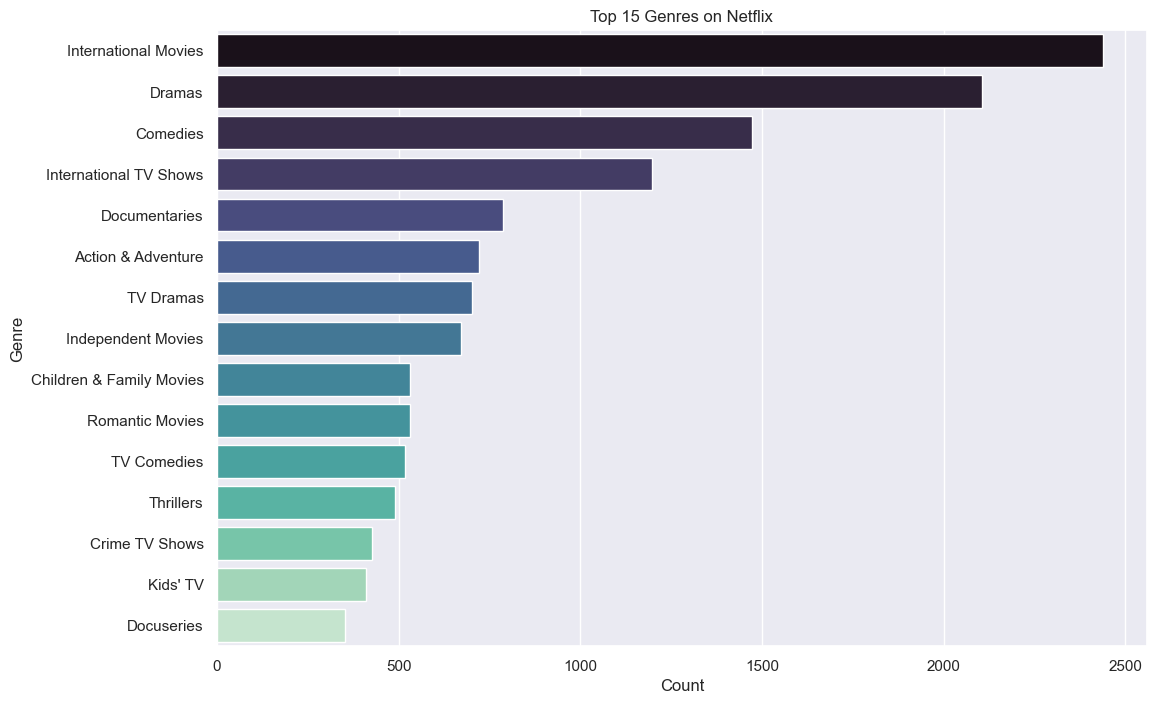

In [21]:
## reset_index(): converts it into a DataFrame
top_genres = genres["genre"].value_counts().reset_index()
top_genres.columns = ["genre", "count"]

top_15_genres = top_genres.head(15)

plt.figure(figsize=(12, 8))
## Hue: Use another categorical column to divide the data into groups and give each group a different color
sns.barplot(y='genre', x='count', data=top_15_genres, palette='mako', hue='genre', legend=False)
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

4.4 What is the distribution of content duration

In [22]:
## Duration for Movies
movies_duration = df[df["type"]=="Movie"].copy()
movies_duration['duration'] = movies_duration["duration"].str.replace(" min", "").astype(int)

## Duration for Tv shows
series_duration = df[df["type"]=='TV Show'].copy()
series_duration["duration"] = series_duration["duration"].str.replace( "Seasons",'').str.replace("Season", '').astype(int)

series_duration


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,2017,7
11,s12,TV Show,1983,Unknown,"Robert Więckiewicz, Maciej Musiał, Michalina O...","Poland, United States",2018-11-30,2018,TV-MA,1,"Crime TV Shows, International TV Shows, TV Dramas","In this dark alt-history thriller, a naïve law...",2018,11
12,s13,TV Show,1994,Diego Enrique Osorno,Unknown,Mexico,2019-05-17,2019,TV-MA,1,"Crime TV Shows, Docuseries, International TV S...",Archival video and new interviews examine Mexi...,2019,5
16,s17,TV Show,Feb-09,Unknown,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",United States,2019-03-20,2018,TV-14,1,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h...",2019,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7767,s7768,TV Show,Zindagi Gulzar Hai,Unknown,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre...",2016,12
7775,s7776,TV Show,Zoids Wild,Unknown,"Kensho Ono, Takahiro Sakurai, Mikako Komatsu, ...",Japan,2020-08-14,2018,TV-Y7,1,"Anime Series, Kids' TV",A quest for freedom and legendary treasure beg...,2020,8
7777,s7778,TV Show,Zombie Dumb,Unknown,Unknown,United States,2019-07-01,2018,TV-Y7,2,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7
7779,s7780,TV Show,Zona Rosa,Unknown,"Manu NNa, Ana Julia Yeyé, Ray Contreras, Pablo...",Mexico,2019-11-26,2019,TV-MA,1,"International TV Shows, Spanish-Language TV Sh...",An assortment of talent takes the stage for a ...,2019,11


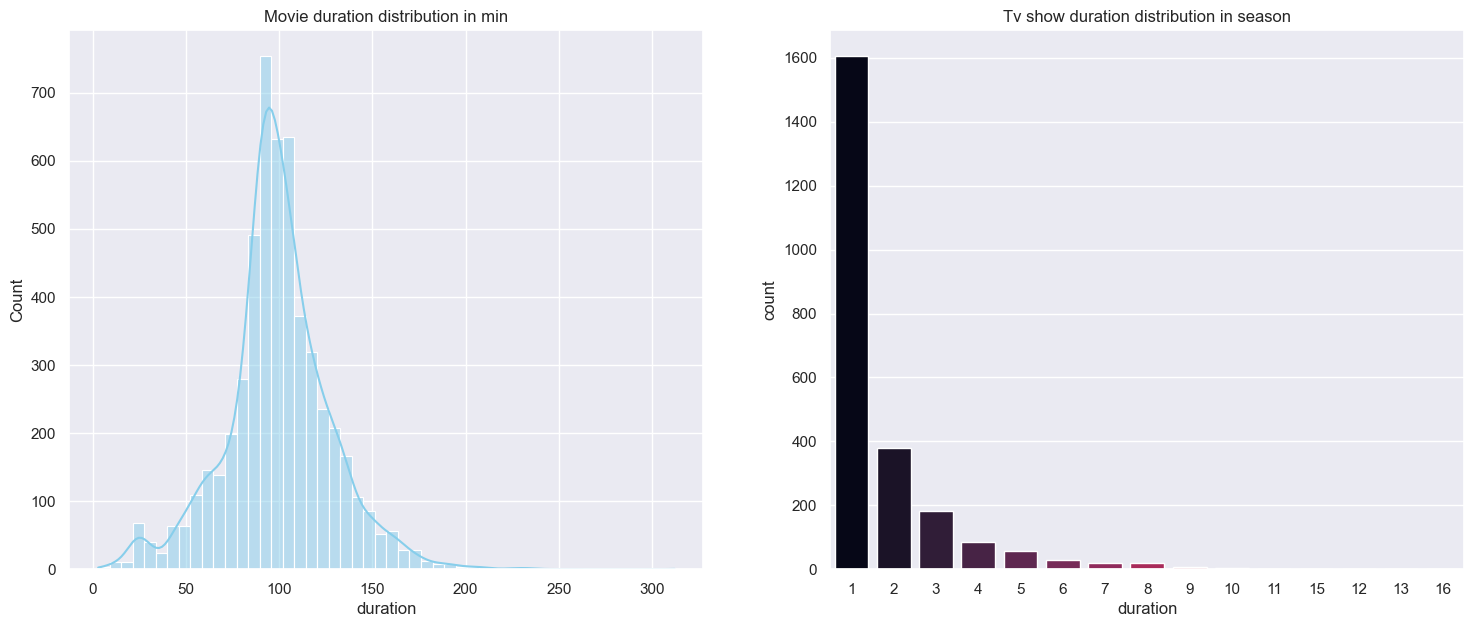

In [23]:
fig, axes = plt.subplots(1,2, figsize=(18,7))

sns.histplot(x='duration', data=movies_duration, ax=axes[0], bins=50, kde=True, color='skyblue').set_title("Movie duration distribution in min")

sns.countplot(ax=axes[1], x='duration', data=series_duration, palette="rocket", order=series_duration["duration"].value_counts().index, hue='duration', legend=False).set_title("Tv show duration distribution in season")


plt.show()


4.5 Where does the content comes from?(Geographical Region)



In [24]:
df["country"].value_counts()

country
United States                                     3051
India                                              923
United Kingdom                                     396
Japan                                              224
South Korea                                        183
                                                  ... 
Germany, United States, United Kingdom, Canada       1
Peru, United States, United Kingdom                  1
Saudi Arabia, United Arab Emirates                   1
United Kingdom, France, United States, Belgium       1
France, Norway, Lebanon, Belgium                     1
Name: count, Length: 681, dtype: int64

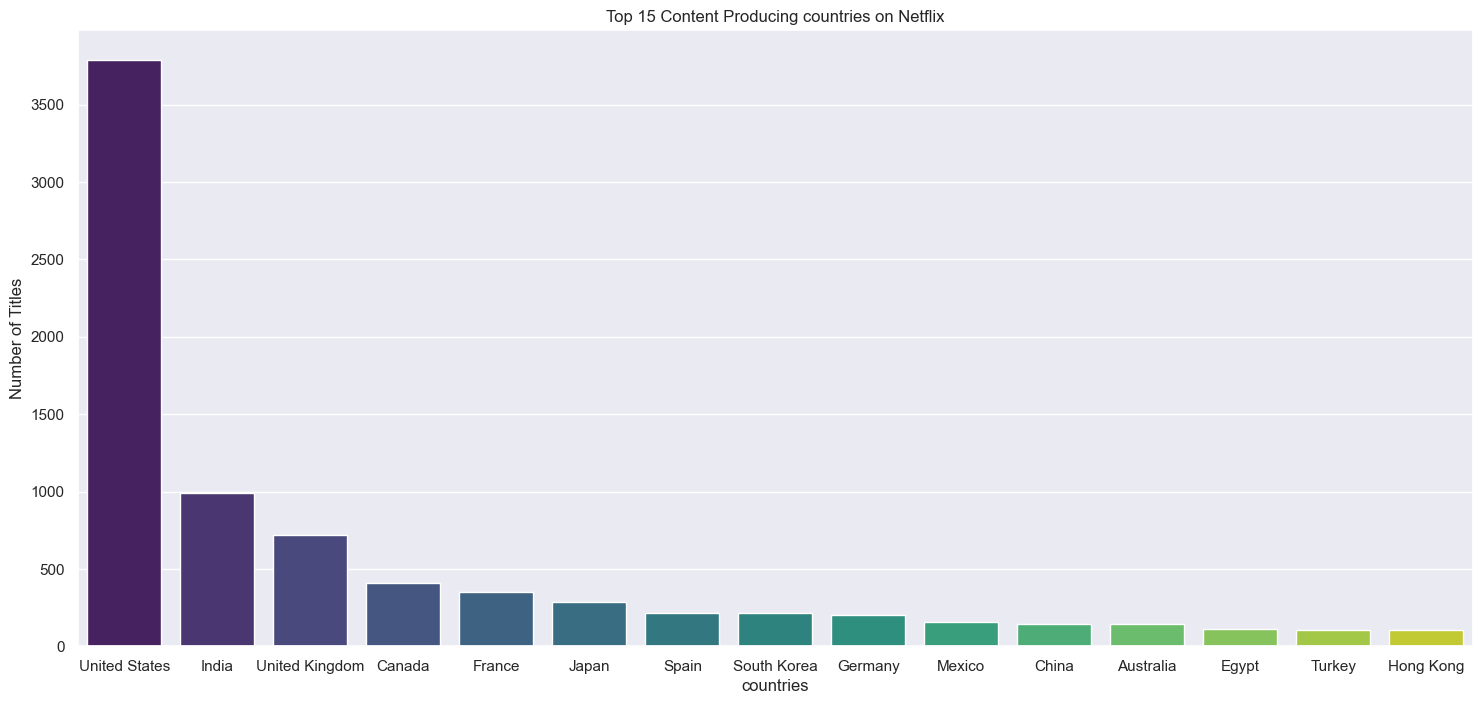

In [25]:
country = df.assign(country = df["country"].str.split(", ")).explode('country')
country_counts = country["country"].value_counts().reset_index()

top_15_countries = country_counts.head(15)

plt.figure(figsize=(18,8))
sns.barplot(data=top_15_countries, x='country', y='count', palette='viridis', hue='country', legend=False)
plt.title("Top 15 Content Producing countries on Netflix")
plt.xlabel("countries")
plt.ylabel("Number of Titles")

plt.show()

4.6 What is the maturity ratings of the content?

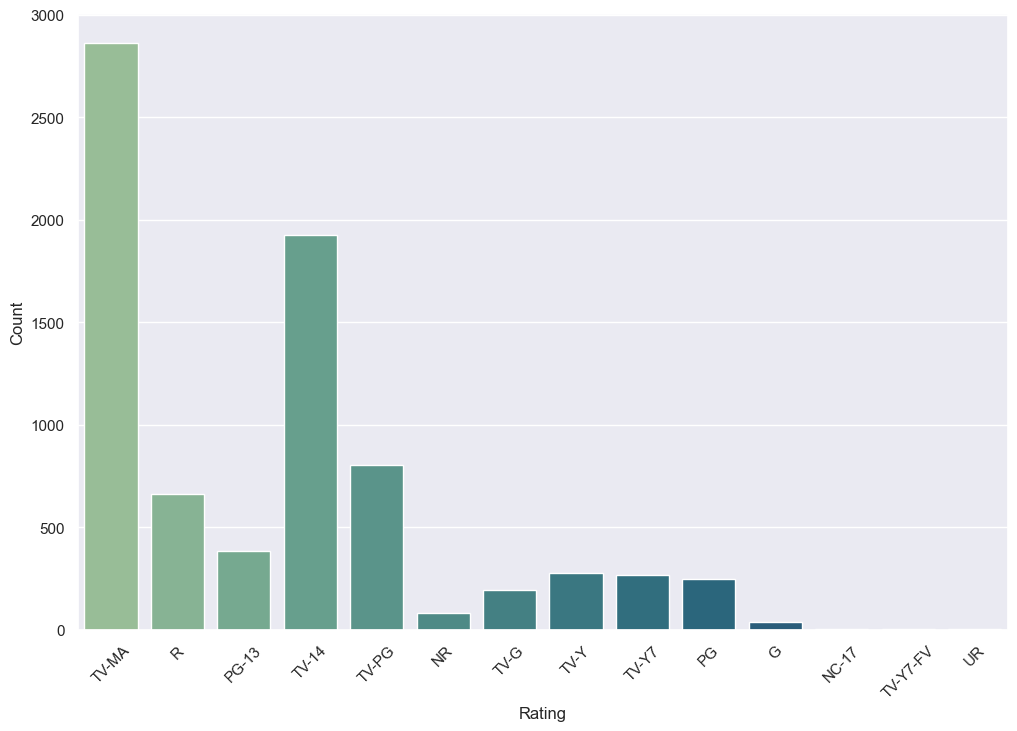

In [26]:
plt.figure(figsize=(12,8))
sns.countplot(x='rating', data=df, palette='crest', hue='rating', legend=False)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45) ## controls the x labels angles
plt.show()

## Step 5: Feature Engineering

Plot distribution based on acquistion strategy of netflix 

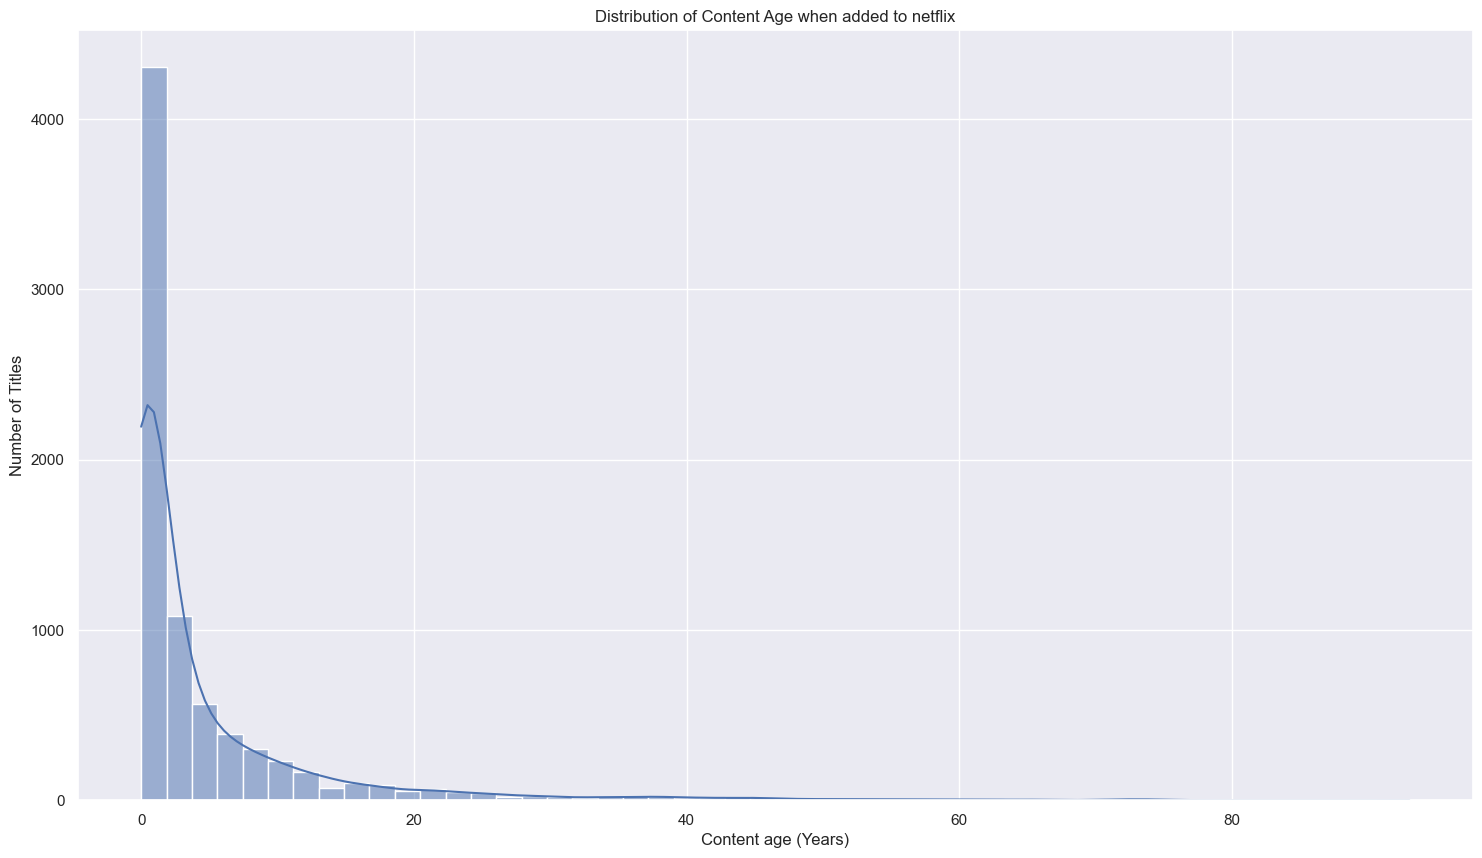

In [27]:
df["age_on_netflix"] = df["year_added"] - df["release_year"]

content_release_age = df[df["age_on_netflix"]>=0]
plt.figure(figsize=(18,10))
sns.histplot(data=content_release_age, x='age_on_netflix', bins=50, kde=True)
plt.title("Distribution of Content Age when added to netflix")
plt.xlabel("Content age (Years)")
plt.ylabel("Number of Titles")
plt.show()

**Key Insights**
* Most content is relatively new when added to Netflix.
* The distribution is highly right-skewed.
* There is a large concentration around 0–5 years of content age.
* A smaller number of titles are much older, creating a long tail.
* Netflix adds both recent and older content, but newer content dominates

### Step 6: Deeper Multivariate Analysis

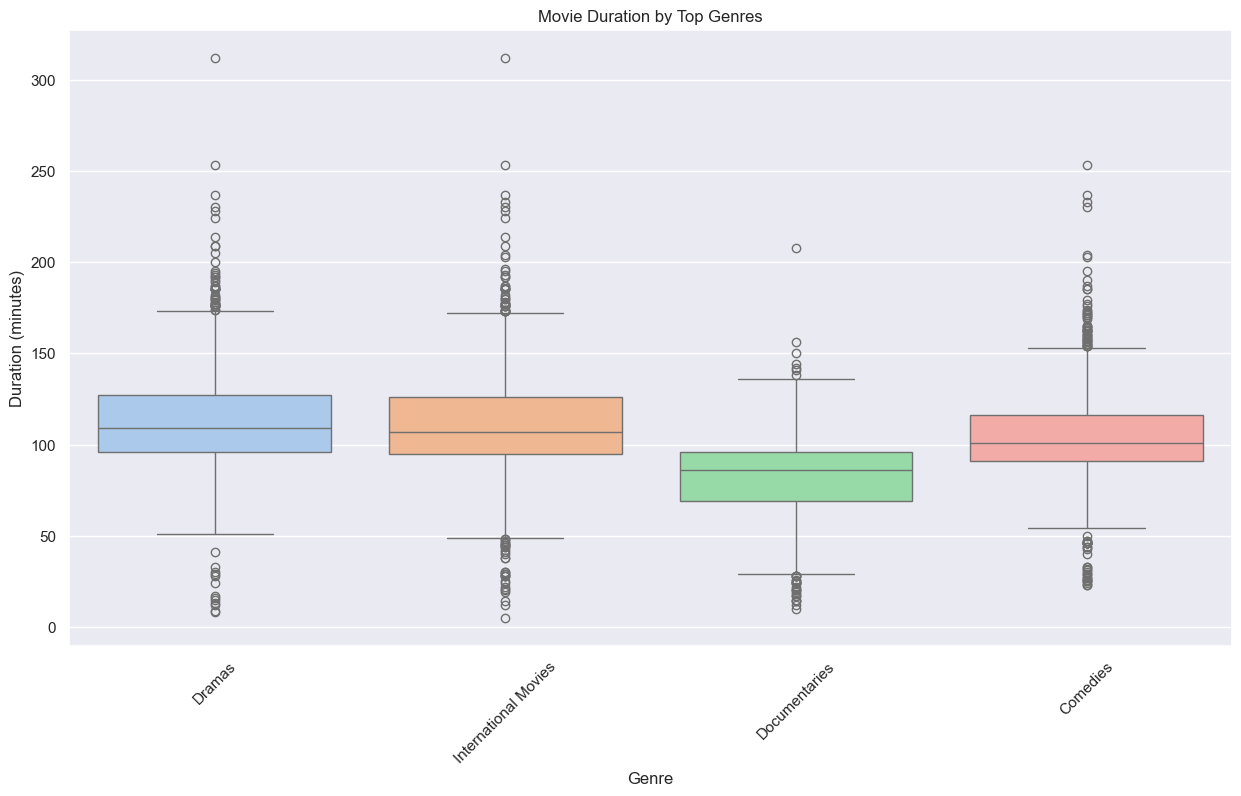

In [28]:
# Analyse Movie Duration across d/f genres

top_genre = genres["genre"].value_counts().index[:5]

genres_movies = genres[
    (genres["type"] == "Movie") &
    (genres["genre"].isin(top_genre))
].copy()

genres_movies["duration_min"] = genres_movies["duration"].str.replace(' min','').astype(int)
genres_movies
plt.figure(figsize=(15,8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title("Movie Duration by Top Genres")
plt.xlabel("Genre")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=45)
plt.show()

### Key Insights

* **Dramas** have a median duration of ~110 minutes.
* **International Movies** are similar, with a median of ~107 minutes.
* **Documentaries** are generally shorter, with a median of ~87 minutes.
* **Comedies** have a median of ~102 minutes.
* All genres contain **many outliers**, especially longer movies exceeding 150 minutes.
* Overall, **Documentaries tend to be shorter**, while **Dramas and International Movies tend to be longer**.


### Step 7: Word Cloud from Content Description

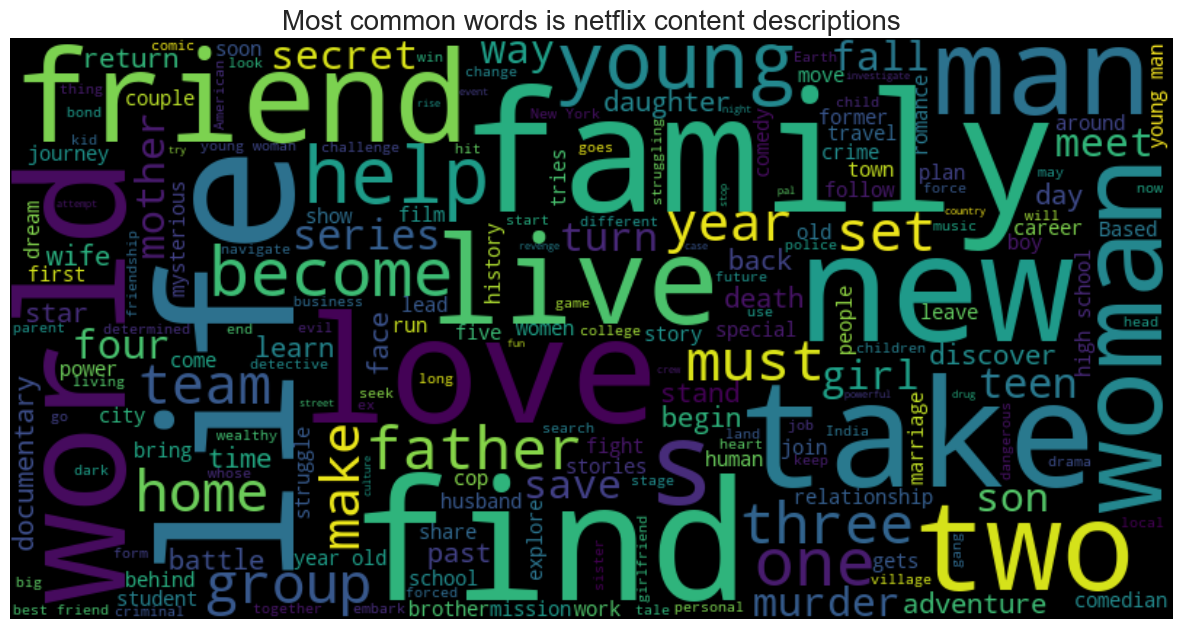

In [29]:
text = " ".join(df["description"])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most common words is netflix content descriptions", fontsize=20)
plt.show()

### Key Insights

* **“Family”, “love”, and “life”** are among the most frequent themes.
* **Relationships** are prominent: *mother, father, husband, wife, son, daughter, friend*.
* **People and characters** are common: *man, woman, girl, boy, young*.
* Many descriptions involve **action/adventure**: *fight, battle, journey, discover, travel, search*.
* **Crime/drama themes** also appear: *murder, criminal, secret, police, death*.
* Overall, Netflix descriptions heavily focus on **people, relationships, life experiences, and conflict**.


# Netflix EDA — Overall Key Insights

### 1. Dataset & Data Cleaning

* Dataset contains **7,787 titles** across **12 columns**.
* **Movies and TV Shows** are the two main content types.
* Missing values were handled for `director`, `cast`, and `country`.
* `date_added` was converted to datetime, enabling **year/month analysis**.
* Multi-valued columns such as `listed_in` and `country` were split and exploded for analysis.

### 2. Content Type

* **Movies dominate Netflix's catalog**: 5,372 movies vs. 2,398 TV Shows.
* Netflix's catalog is therefore more **movie-oriented than TV-show-oriented**.

### 3. Content Added Over Time

* Content additions grew rapidly, particularly between **2015–2019**.
* Movies consistently had **more additions than TV Shows**.
* Movie additions peaked at nearly **1,500 titles in 2019**.
* TV Show additions peaked around **700 titles in 2020**.
* Additions dropped noticeably after 2019/2020.

### 4. Genres

* Netflix has a **wide variety of genres**, with 491 unique genre combinations in `listed_in`.
* **Dramas, International Movies, Comedies, and Documentaries** are among the prominent individual genres.
* Since titles can belong to multiple genres, `explode()` was used to analyze genres individually.

### 5. Content Duration

* Movie durations are concentrated roughly around **90–120 minutes**.
* Very short and very long movies occur less frequently.
* TV Shows are mostly concentrated around **1–3 seasons**.
* Movie duration varies by genre:

  * **Dramas & International Movies:** generally longer.
  * **Documentaries:** generally shorter.
  * **Comedies:** fall between these groups.
* There are several **duration outliers**, particularly for longer movies.

### 6. Geographic Distribution

* **United States** is the largest contributor to Netflix's catalog.
* **India** is the second-largest contributor, followed by countries such as the **United Kingdom, Japan, and South Korea**.
* This shows a strong presence of **both Western and international content**.

### 7. Maturity Ratings

* Netflix's catalog is heavily represented by **mature/adult-oriented ratings**, particularly TV-MA.
* Ratings such as **TV-14 and R** also form significant portions of the catalog.
* This indicates substantial content aimed at **teen and adult audiences**.

### 8. Content Age at Acquisition

* Most titles were added to Netflix **within a few years of their release**.
* The distribution is **strongly right-skewed**, with a large concentration around **0–5 years**.
* A smaller number of much older titles create a **long tail**.
* Netflix therefore acquires a mixture of **recent and older content**, with recent content dominating.

### 9. Description Analysis

The word cloud shows that Netflix descriptions frequently revolve around:

* **Relationships:** family, mother, father, husband, wife, son, daughter, friend.
* **People:** man, woman, girl, boy, young.
* **Life & emotions:** love, life, home.
* **Conflict/action:** fight, battle, murder, criminal, police, secret.
* **Adventure:** journey, discover, travel, search.

### Overall Conclusion

> **Netflix's catalog is movie-dominated, expanded rapidly during 2015–2019, has strong international representation, focuses heavily on mature audiences, and contains mostly relatively recent content. Dramas and international content are prominent, while descriptions commonly revolve around people, relationships, life, and conflict.**


Submission Q's

* How has the distribution of content ratings changed over time?
* Is there a relationship between content age and its type (Movie vs. TV Show)?
* Can we identify any trends in content production based on the release year vs. the year added to Netflix?
* What are the most common word pairs or phrases in content descriptions?
* Who are the top directors on Netflix?

1. How has the distribution of content ratings changed over time?


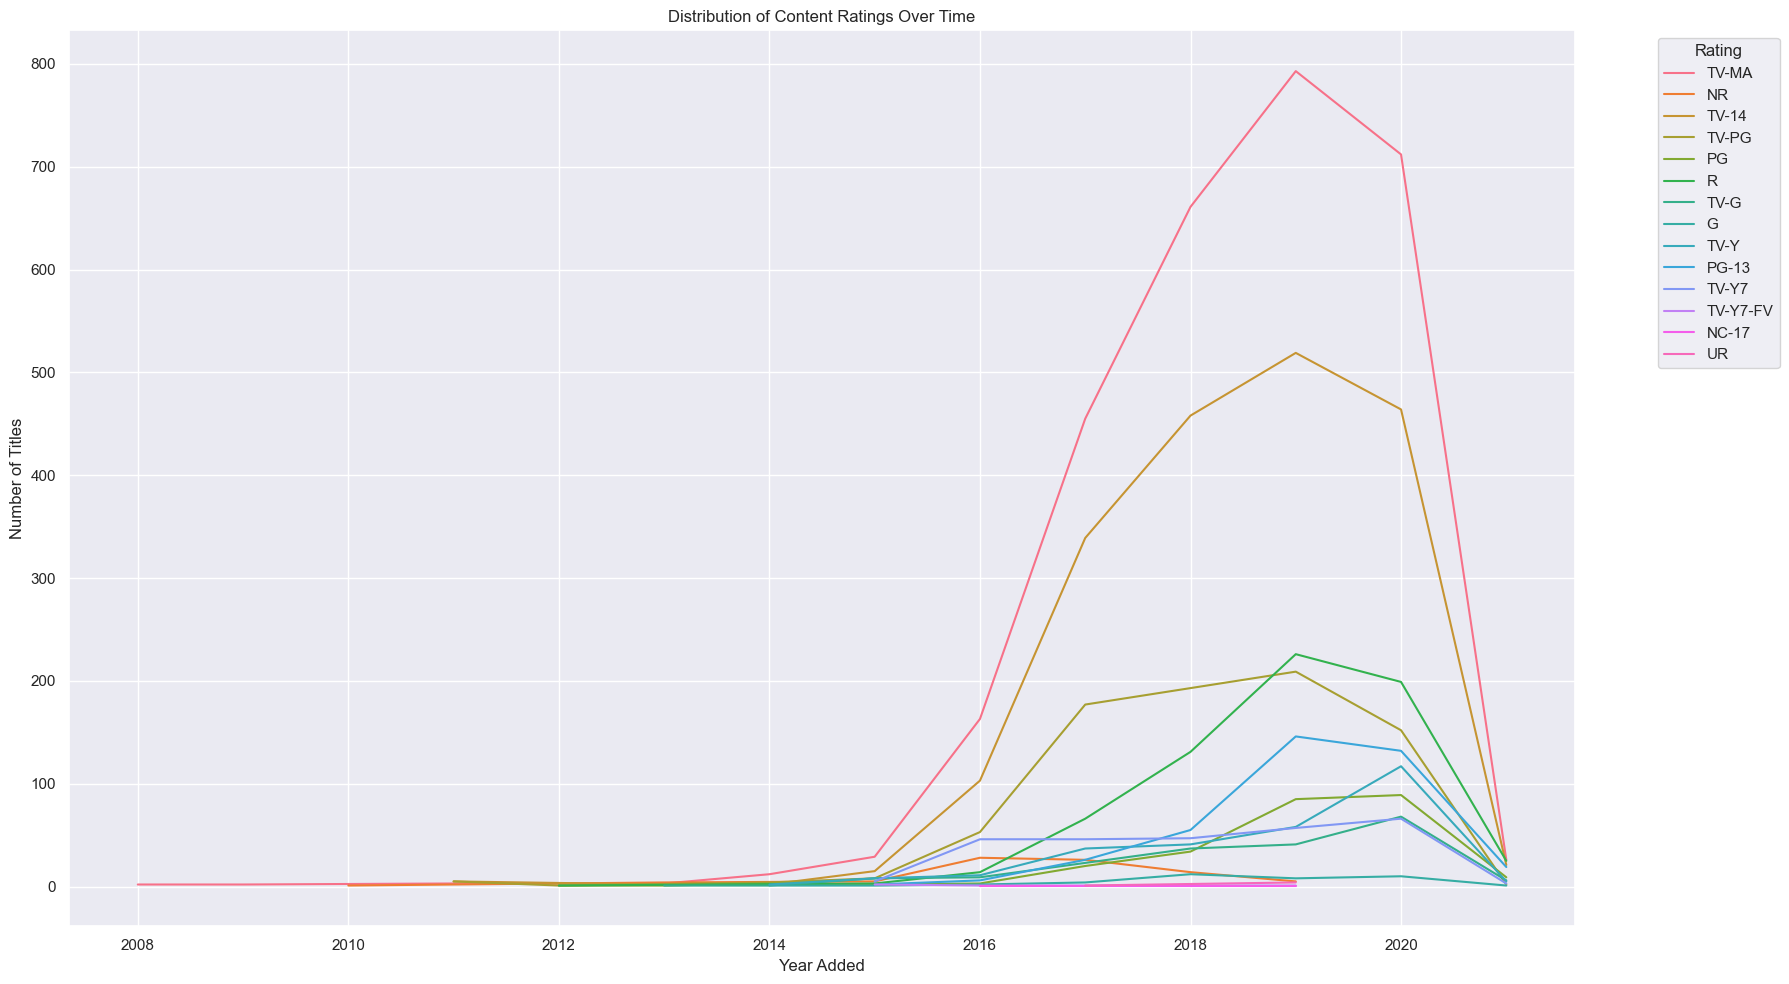

In [30]:
## Distribution of content ratings changed over time

df["year_added"] = pd.to_datetime(df["date_added"]).dt.year

rating_time = (
    df.groupby(["year_added", "rating"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(18, 10))

sns.lineplot(
    data=rating_time,
    x="year_added",
    y="count",
    hue="rating"
)

plt.title("Distribution of Content Ratings Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Answer:

Increase in Mature content over the years (TV-MA)
For most years (exception being 2011-2013), Netflix added in more movies in the mature content (TV-MA) category than any other rating.
Similar distribution seen in series too - but 2015-2017 period saw a higher number of TV-14 than TV-MA series
Only two series were Rated R: in the years 2015 and 2016

2. Is there a relationship between content age and its type (Movie vs. TV Show)?

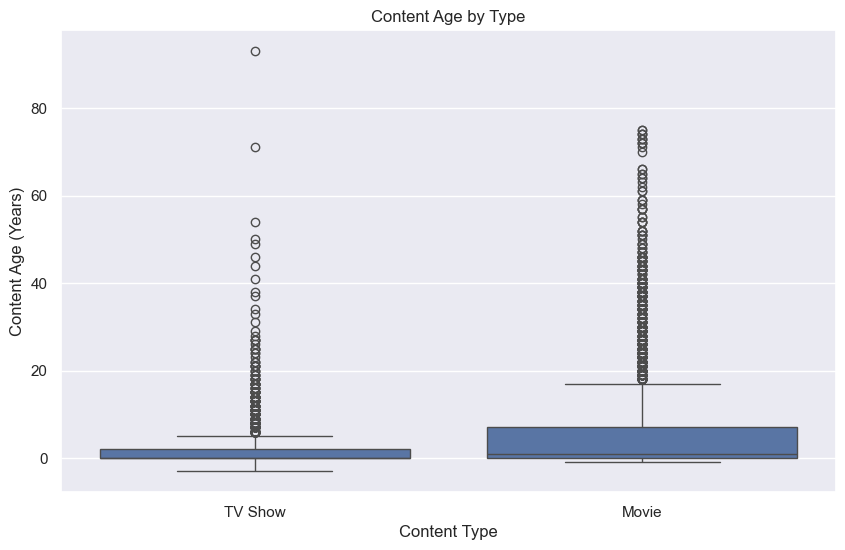

In [31]:
df["content_age"] = df["year_added"] - df["release_year"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="type",
    y="content_age"
)

plt.title("Content Age by Type")
plt.xlabel("Content Type")
plt.ylabel("Content Age (Years)")

plt.show()

Answer:

Netflix tends to add in newer shows and movies as we saw above before.
Most movies tend to be between the age 0 to 10 years, whereas most shows tend to be between the age 0 to 5 years
However, there are quite a few series and movies that do not follow this rule
- TV shows that are added in, span a larger age range than movies: with the farthest outlier being over 80 years old
- Though, the number of TV shows added outside the general age-range is lesser. Meaning: Netflix is more likely to add in older movies than older TV shows

3. Can we identify trends in content production based on release year vs. year added to Netflix?

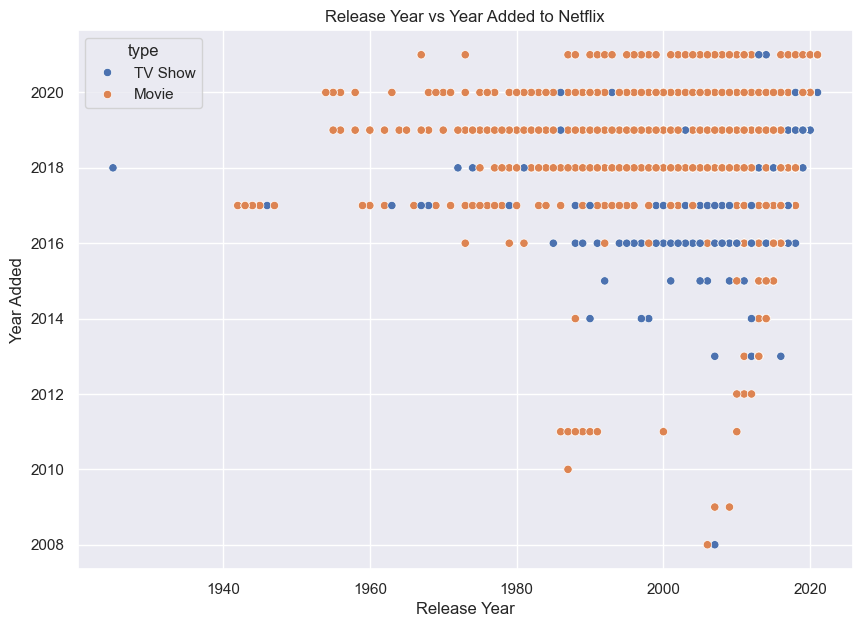

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="release_year",
    y="year_added",
    hue="type"
)

plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Release Year")
plt.ylabel("Year Added")

plt.show()

Answer:

The density plot shows a much clearer picture
Most years netflix added in shows and movies that were recently released
Netflix added in more older shows between the years 2018 and 2020

4. What are the most common word pairs or phrases in content descriptions?

In [33]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\psr-007\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

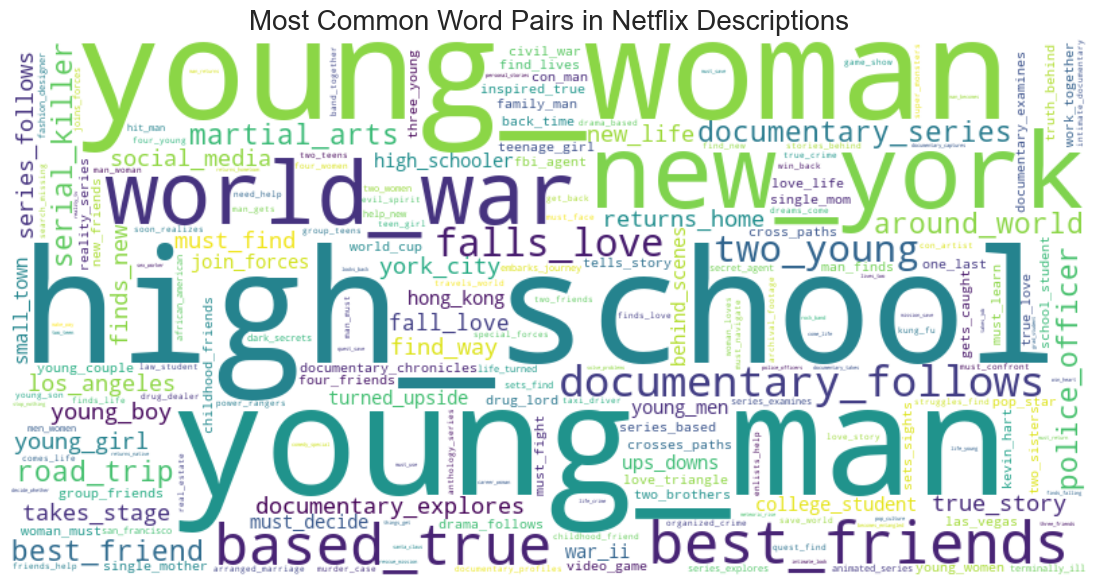

In [36]:
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords

stopwords = set(stopwords.words('english'))
all_word = ' '.join(df["description"].dropna()).lower().split()
filtered_words = [word for word in all_word if word.isalpha() and word not in stopwords]

bigrams = ['_'.join([filtered_words[i], filtered_words[i+1]]) for i in range(len(filtered_words)-1)]

bigrams_count = Counter(bigrams)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(bigrams_count)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Word Pairs in Netflix Descriptions', fontsize=20)
plt.show()

Answer:

* "High school" seems to be the most common theme
* Closely followed by young man/ young woman
* New york, world war, documentary series, best friend all appear often too
* *hows that Netflix has both factual content and stories that focus on different life stages and cultural backdrops.

5. Who are the top directors on Netflix?

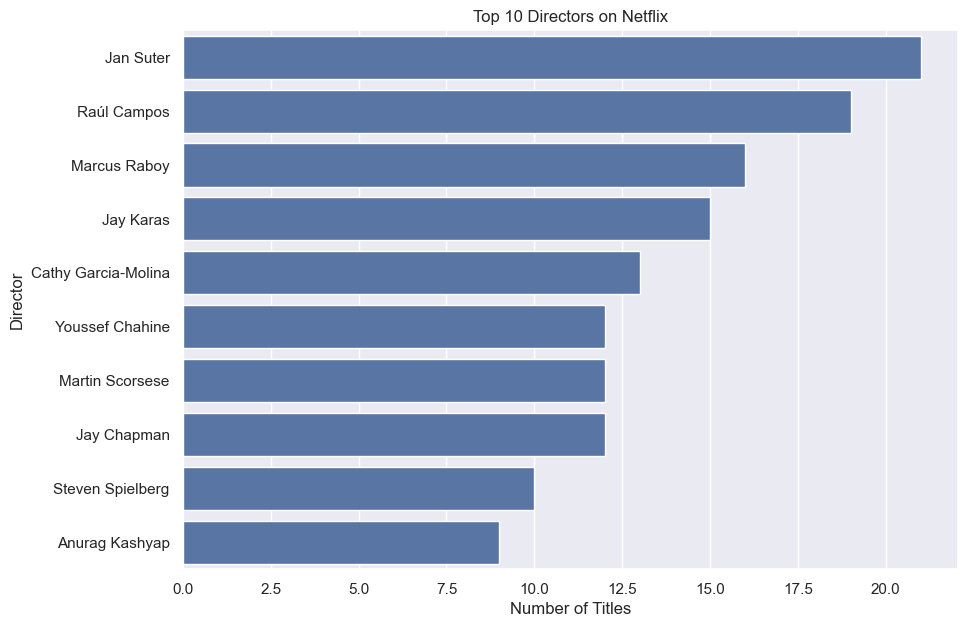

In [49]:
directors = (
    df.dropna(subset=["director"])
      .assign(director=df["director"].str.split(", "))
      .explode("director")
)

top_directors = (
    directors["director"]
    .value_counts()
    .drop("Unknown", errors="ignore")
    .head(10)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()